# Melville Bugt dyke swarm ca. 1630 Ma paleomagnetic pole

## Geologic context

The Melville Bugt dyke swarm trends north-northwest for ~1000 km along the west coast of Greenland (Halls, Hamilton & Denyszyn, 2011). The dykes are alkaline trachybasalts, 100-200 m wide, with a remarkably constant geochemistry along the swarm. Halls et al. proposed the swarm as a possible Laurentia-Greenland connection to the 1.5-1.6 Ga Fennoscandian rapakivi-granite province. U-Pb baddeleyite dating gives ca. 1630 Ma (four dated dykes: 1622.1 ± 3.2, 1629.4 ± 0.8, 1632.0 ± 1.1, 1635.0 ± 2.7 Ma, all 2σ; Halls et al., 2011).

## Paleomagnetic and rock magnetic data

This notebook recreates the Melville Bugt pole at the site level from the 9 dykes that carry a primary magnetite remanence (Halls et al., 2011). The swarm is of mixed polarity (both polarities present, but the reversal test is equivocal), and chilled-margin sampling with geochemical fingerprinting was used to avoid double-counting duplicate dykes.

## Age Constraints

- Adopted bracket: nominal age 1630 Ma, lomagage 1619 Ma, himagage 1638 Ma.
- Compilation method note: Halls et al., 2011 developed U-Pb baddeleyite ID-TIMS concordia upper intercept ages from four dikes that have ages of 1622±3Ma, 1629±1Ma, 1632±1Ma, 1635±3Ma. Then Klausen and Nilsson, 2019 dated another dike that are farther SE that yielded an age of 1630±4Ma U–Pb baddeleyite age interpreted to indicate that the dike swarm has a larger extend then previously estimated. All four dated dykes span ~1622-1635 Ma, and all four (including the youngest, the 1622 Ma Olrik fjord dyke = site OF) are among the nine dykes averaged in the pole. The pole therefore time-averages the swarm's ~13 Myr emplacement, so the nominal age is taken as 1630 Ma (the mean of the four dated pole dykes, and the literature 'ca. 1630 Ma' age of the swarm) with a 1619-1638 Ma bracket (the 2σ envelope of those dates).

## References

### Paleomagnetism and rock magnetism
- Halls, H. C., Hamilton, M. A., & Denyszyn, S. W. (2011). The Melville Bugt Dyke Swarm of Greenland: A Connection to the 1.5-1.6 Ga Fennoscandian Rapakivi Granite Province? In R. K. Srivastava (Ed.), Dyke Swarms:Keys for Geodynamic Interpretation: Keys for Geodynamic Interpretation (pp. 509–535). Springer. https://doi.org/10.1007/978-3-642-12496-9_27


### Geochronology / age-constraint note (compilation)
- Halls, H. C., Hamilton, M. A., & Denyszyn, S. W. (2011). The Melville Bugt Dyke Swarm of Greenland: A Connection to the 1.5-1.6 Ga Fennoscandian Rapakivi Granite Province? In R. K. Srivastava (Ed.), Dyke Swarms:Keys for Geodynamic Interpretation: Keys for Geodynamic Interpretation (pp. 509–535). Springer. https://doi.org/10.1007/978-3-642-12496-9_27
- Klausen, M. B., & Nilsson, M. K. M. (2019). The Melville Bugt Dyke Swarm across SE Greenland: A closer link to Mesoproterozoic AMCG-complexes. Precambrian Research, Dyke Swarms: Keys for Precambrian Paleogeographic Reconstruction, 329, 88–107. https://doi.org/10.1016/j.precamres.2018.06.001

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data

Site means are loaded from `../data/1630_Melville_Bugt/`. The pole uses the 9
dykes with a stable primary direction; secondary-component and present-field
(PEF) sites, and the OF chilled margin (the margin of the OF dyke), are excluded.
Directions are in-situ (dykes).

In [2]:
sites_geo, _ = pt.load_magic_sites('../data/1630_Melville_Bugt/sites.txt')
primary = sites_geo[(sites_geo['dir_comp_name'] == 'primary') &
                    (sites_geo['vgp_lat'].notna()) &
                    (sites_geo['site'] != 'OF Margin')].reset_index(drop=True)
study_lat = round(primary['lat'].mean(), 1)
study_lon = round(primary['lon'].mean(), 1)
print(f'{len(primary)} dykes for the pole; study locality ~{study_lat} N, {study_lon} E')
primary[['site', 'lat', 'lon', 'dir_dec', 'dir_inc', 'dir_alpha95', 'dir_k',
         'dir_n_samples', 'vgp_lat', 'vgp_lon']]

9 dykes for the pole; study locality ~74.4 N, 301.6 E


,site,lat,lon,dir_dec,dir_inc,dir_alpha95,dir_k,dir_n_samples,vgp_lat,vgp_lon
0,MB1,69.8669,309.3799,39.3,-44.5,7.0,64.0,8.0,10.1,274.1
1,MB2,69.8984,309.5521,26.9,-14.9,11.7,62.0,4.0,-10.4,282.5
2,MB4,74.4829,303.6652,30.3,-29.3,9.1,72.0,5.0,2.2,274.6
3,MB5,74.5579,303.7798,209.1,46.6,4.9,186.0,6.0,14.2,277.5
4,MB7,74.2886,303.7271,51.9,-8.5,9.6,64.0,5.0,-5.4,251.7
5,MB9,73.9129,304.0582,201.2,50.1,5.6,142.0,6.0,15.7,285.2
6,QT,77.4781,293.5744,195.9,28.8,8.8,41.0,9.0,3.3,278.2
7,JP,77.5933,293.1183,209.1,44.2,3.0,40.0,7.0,15.0,266.2
8,OF,77.1058,293.7330,13.1,-6.7,10.5,25.0,7.0,-9.2,280.5


## Mean pole and the reversal test

The swarm carries both normal and reversed dykes ~180° apart (an equivocal reversal
test); polarity is unified before the Fisher mean.

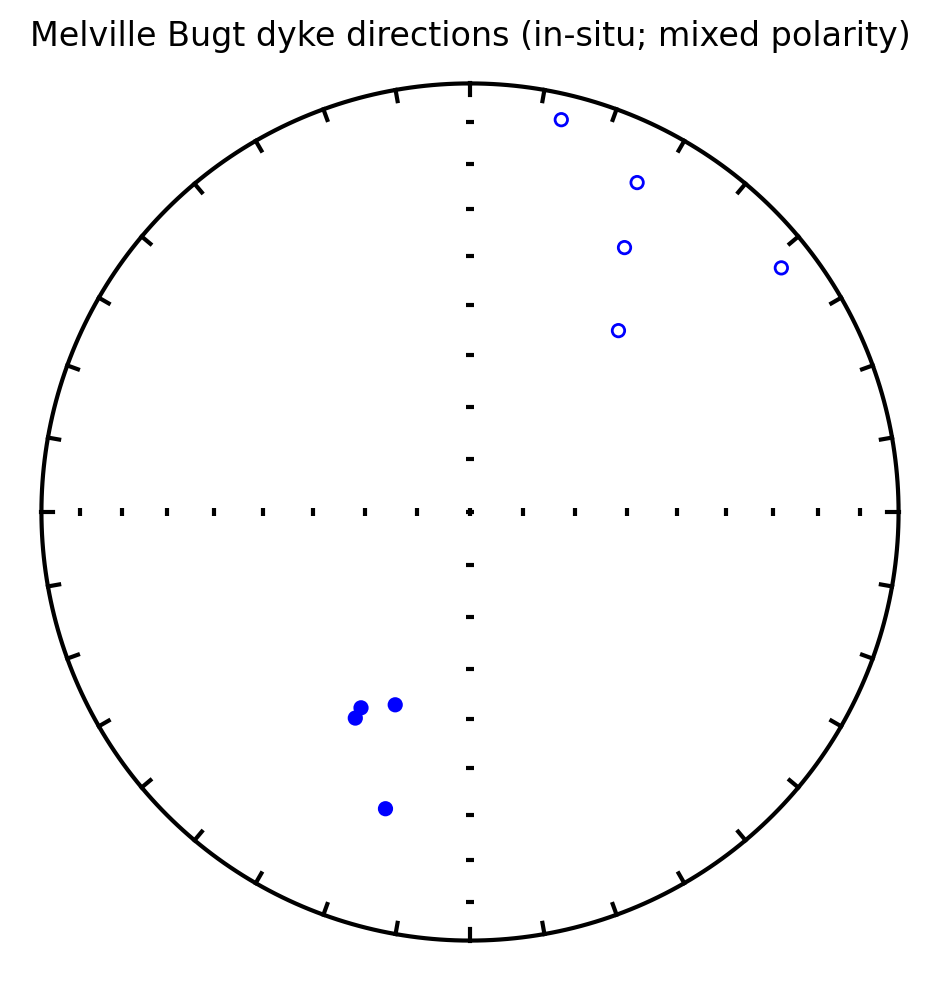

In [3]:
ipmag.plot_net()
ipmag.plot_di(primary['dir_dec'].tolist(), primary['dir_inc'].tolist(),
              color='blue', marker='o')
plt.title('Melville Bugt dyke directions (in-situ; mixed polarity)')
plt.show()

9 directions (polarity 1: 4, polarity 2: 5)

McFadden & McElhinny (1990) reversal test
------------------------------------------
Results of Watson V test: 

Watson's V:           8.3
Critical value of V:  7.8
"Fail": Since V is greater than Vcrit, the two means can
be distinguished at the 95% confidence level.

M&M1990 classification:

Angle between data set means: 22.5
Critical angle for M&M1990:   21.8


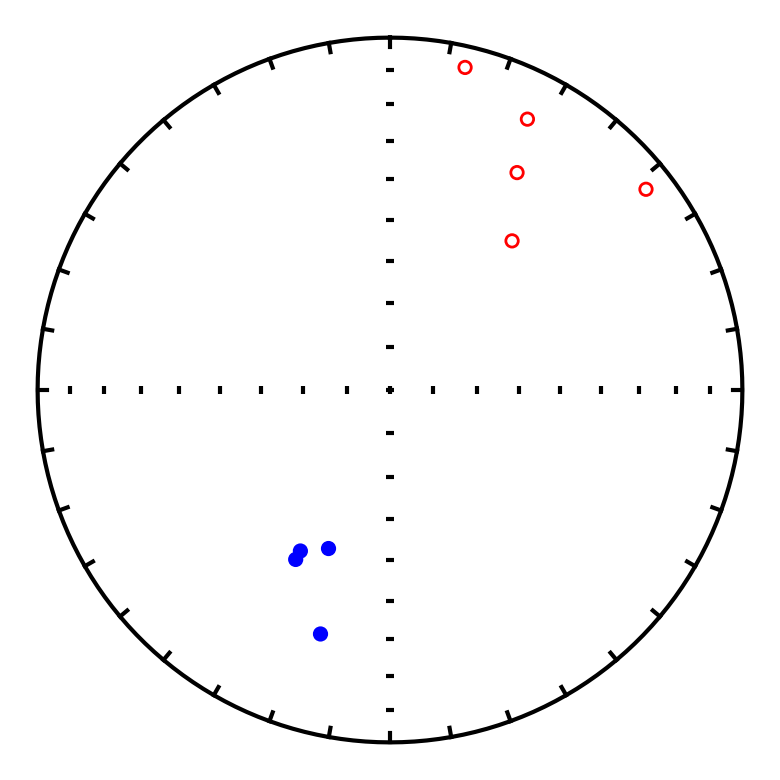


Bootstrap reversal test
------------------------------------------


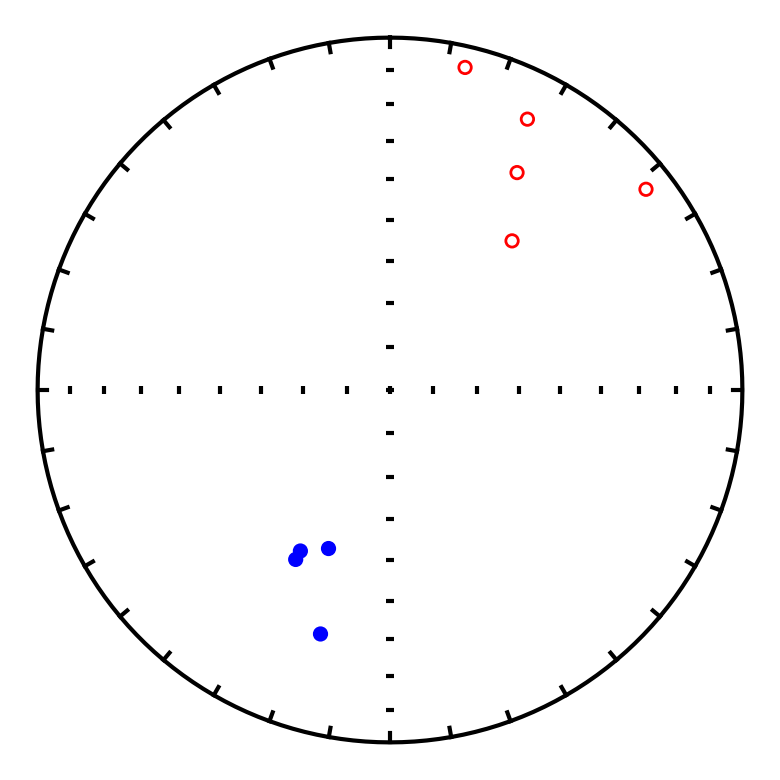

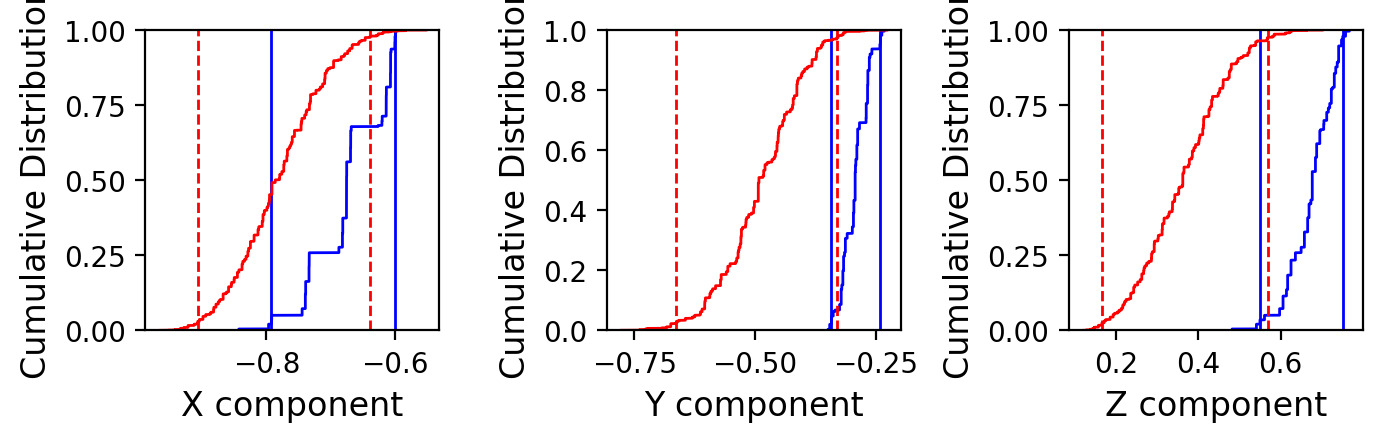

Pass


In [4]:
# McFadden & McElhinny (1990) and bootstrap reversal tests on the mixed-polarity
# dykes (4 normal, 5 reversed)
_ = pt.reversal_test(primary, plot=True, random_seed=1)

Plon: 274.5  Plat: 4.0
Number of directions in mean (n): 9
Angular radius of 95% confidence (A_95): 9.3
Precision parameter (k) estimate: 31.3

prior compilation (GPMDB 9495): 5 N / 273.8 E, A95 8.7, N=9 (reported at the +5 pole;
Halls et al. 2011 report the -5 S antipode)


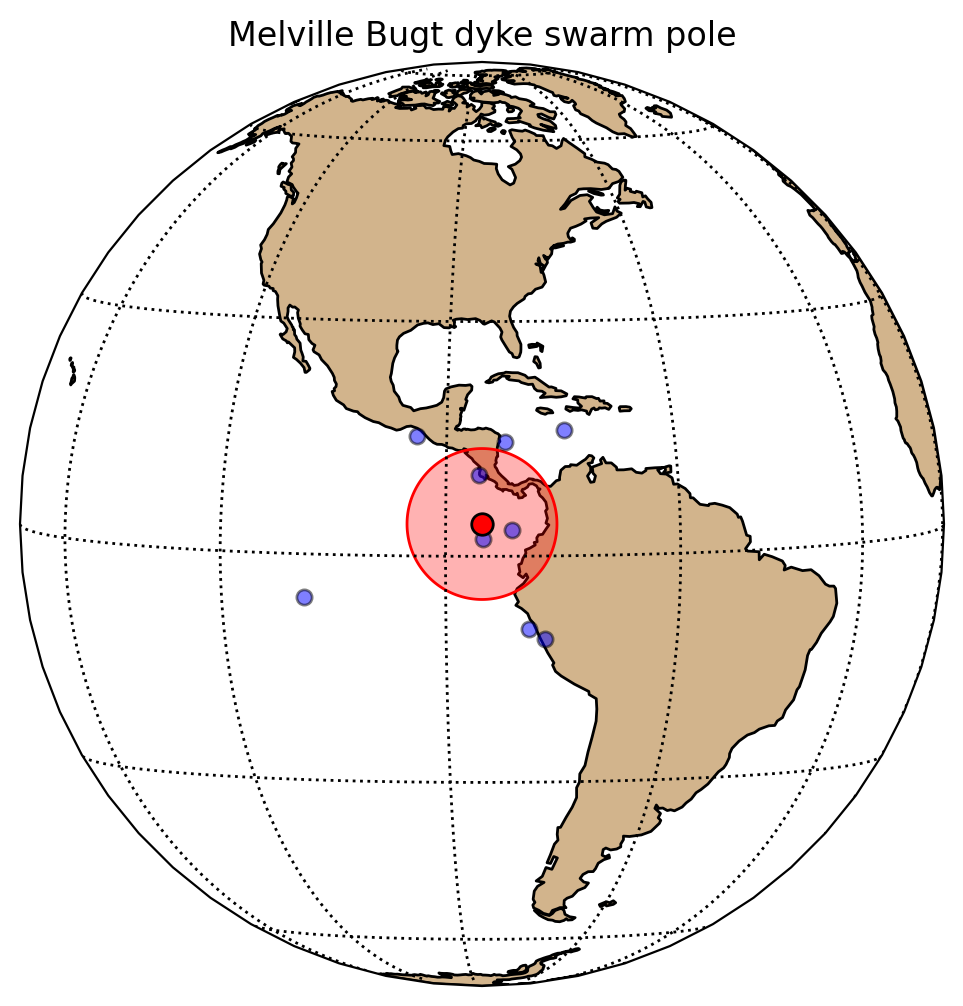

In [5]:


vgp_block, pole_mean = pt.compute_mean_pole(primary, unify_polarity=True)
ipmag.print_pole_mean(pole_mean)
print('\nprior compilation (GPMDB 9495): 5 N / 273.8 E, A95 8.7, N=9 (reported at the +5 pole;')
print('Halls et al. 2011 report the -5 S antipode)')
_ = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'], figsize=(6, 6))
plt.title('Melville Bugt dyke swarm pole')
plt.show()

In [6]:
dir_block, dir_mean = pt.compute_mean_direction(primary, unify_polarity=True)
ipmag.print_direction_mean(dir_mean)

Dec: 208.5  Inc: 31.0
Number of directions in mean (n): 9
Angular radius of 95% confidence (a_95): 13.1
Precision parameter (k) estimate: 16.5


## Paleosecular variation and VGP-shape diagnostics

A_95 of 9.3 passes Deenen et al. (2011) criteria of being between 5.0 and 20.5 for this number of sites


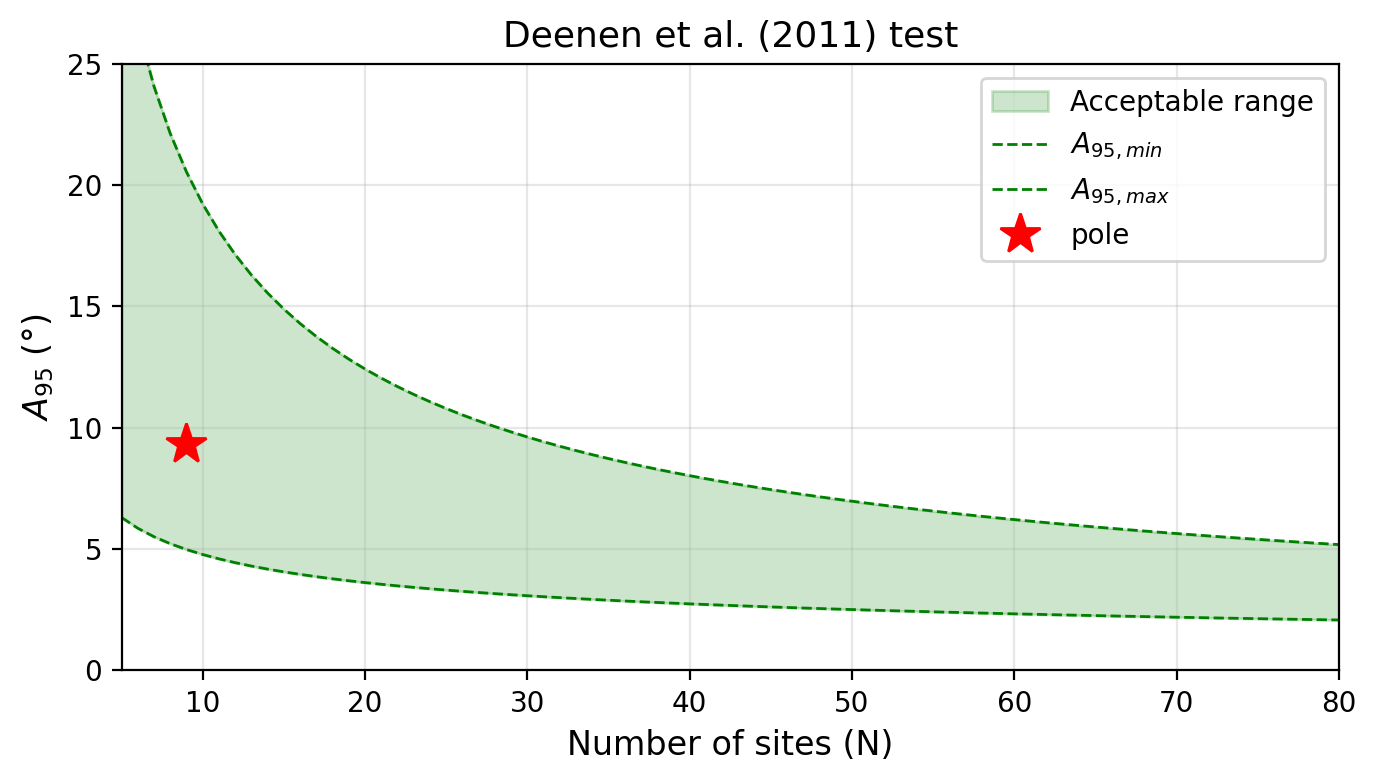

In [7]:
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
_ = pt.plot_Deenen_test(pole_mean)

In [8]:
fishqq_result = pt.fishqq_vgps(primary, unify_polarity=True)
fishqq_result

you need N> 10 for at least one mode


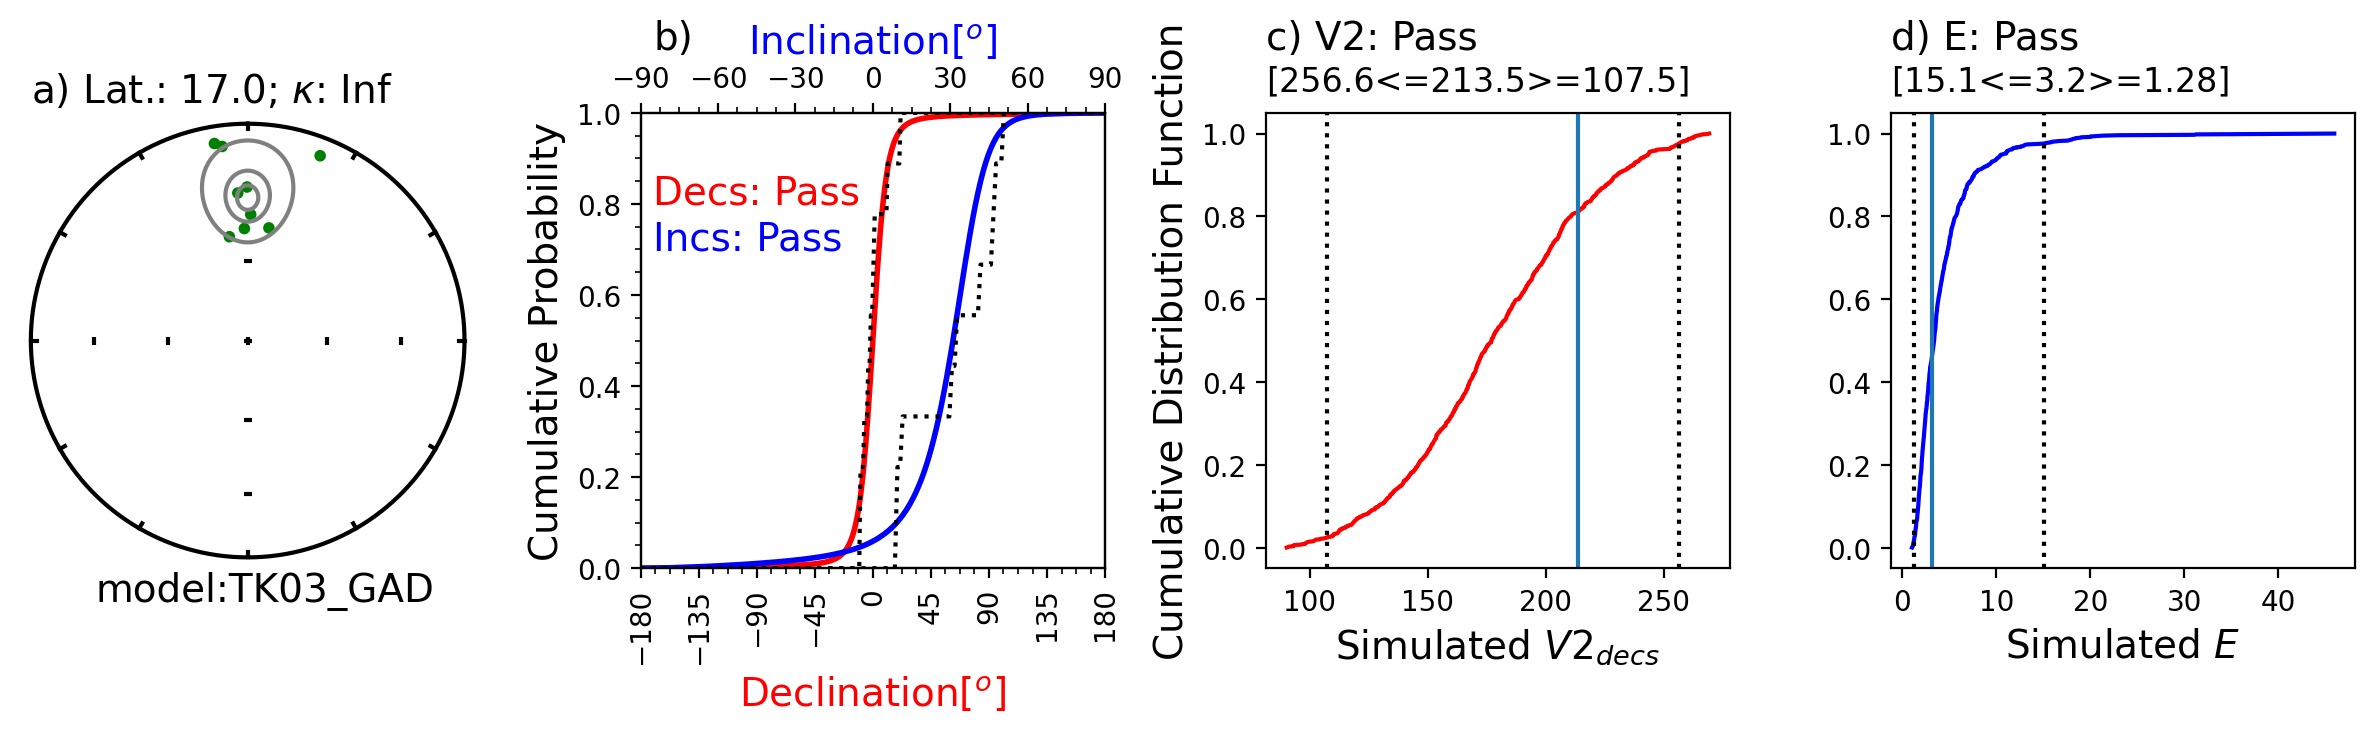

paleolatitude = 17.0 deg; elongation E = 3.20 (consistent with TK03.GAD)


In [9]:
try:
    svei_result = pt.svei_test_vgps(primary, study_lon, study_lat, model='TK03_GAD', plot=True)
except TypeError:
    svei_result = pt.svei_test_vgps(primary, study_lon, study_lat, model='TK03_GAD', plot=False)
    print('(SVEI elongation plot skipped: E below the TK03.GAD model minimum)')
print(f"paleolatitude = {svei_result['lat']:.1f} deg; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")

## Euler rotation into the Laurentia reference frame

These dykes belong to the Laurentia-Greenland terrane, so the pole must be restored into the Laurentia reference frame before it is compared with the Laurentia APWP. The Greenland-to-Laurentia rotation of Roest & Srivastava (1989), associated with Cenozoic opening of Baffin Bay and the Labrador Sea, is applied with `pmag.pt_rot`: Euler pole 67.5 deg N / -118.5 deg E, angle -13.8 deg. This is the same rotation `get_Laurentia_poles` uses to place the Greenland comparison poles into Laurentia coordinates.

In [10]:
euler_greenland = pt.TERRANE_EULER_POLES['Laurentia-Greenland']   # [67.5, -118.5, -13.8]; Roest & Srivastava (1989)
rlat, rlon = pmag.pt_rot(euler_greenland, [pole_mean['inc']], [pole_mean['dec']])
pole_rotated = {'inc': rlat[0], 'dec': rlon[0], 'alpha95': pole_mean['alpha95']}
print(f"unrotated (present-day Greenland frame): {pole_mean['inc']:.1f} N / {pole_mean['dec']:.1f} E")
print(f"rotated into the Laurentia frame:        {pole_rotated['inc']:.1f} N / {pole_rotated['dec']:.1f} E")

unrotated (present-day Greenland frame): 4.0 N / 274.5 E
rotated into the Laurentia frame:        1.6 N / 262.0 E


## The Melville Bugt pole in the context of the Laurentia APWP

The pole is shown in its unrotated position (present-day Greenland coordinates, off the Laurentia path) and rotated into the Laurentia frame (restored onto the path). The comparison APWP poles are all shown in Laurentia coordinates.

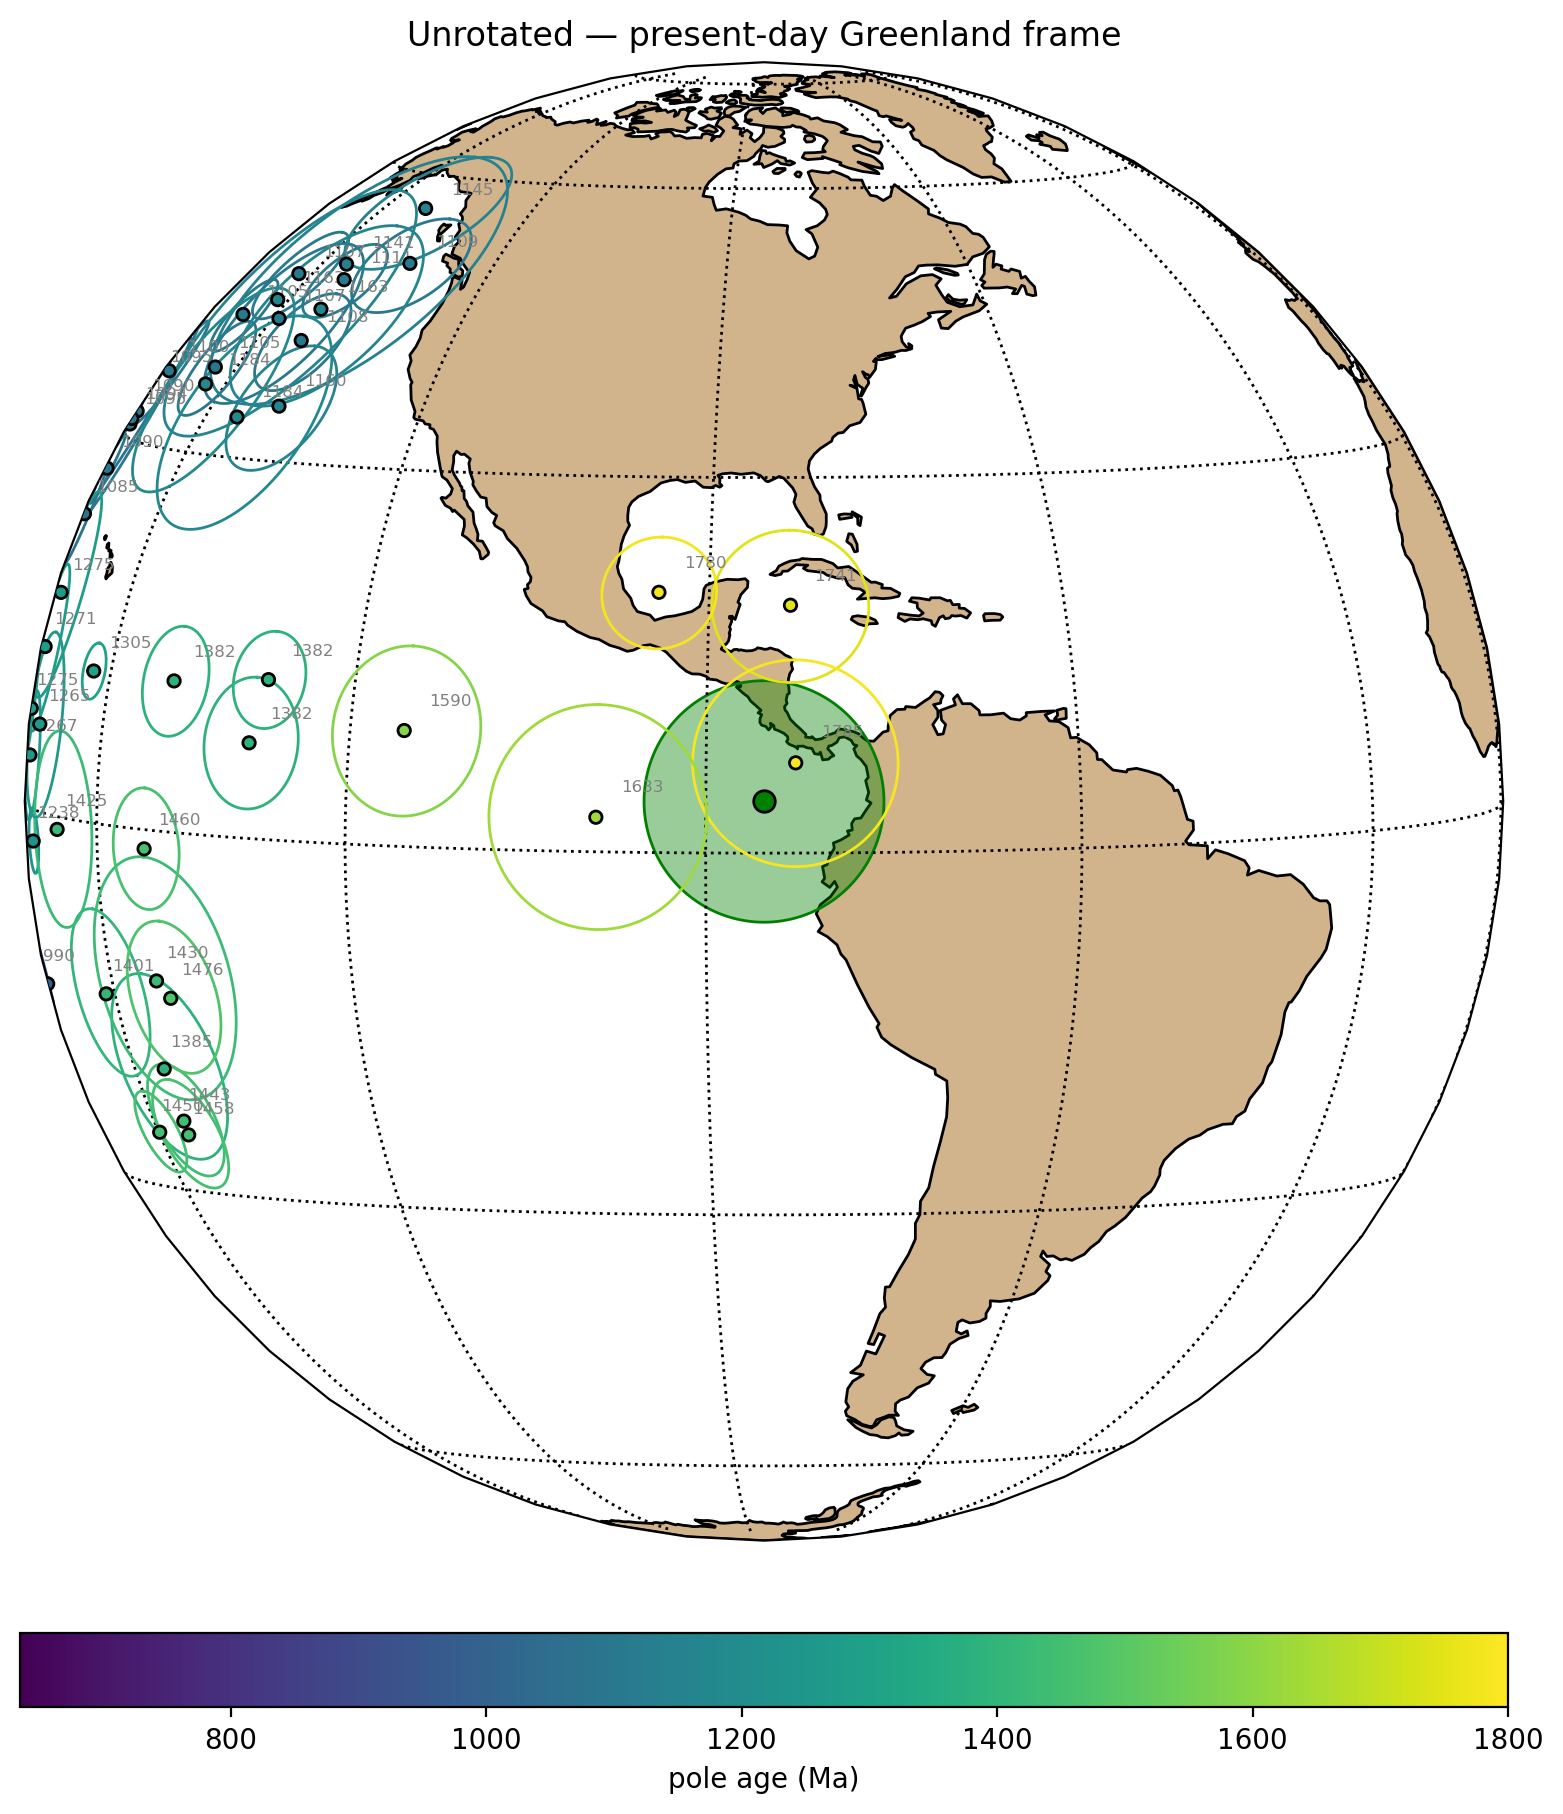

In [11]:
Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.title('Unrotated \u2014 present-day Greenland frame')
plt.show()

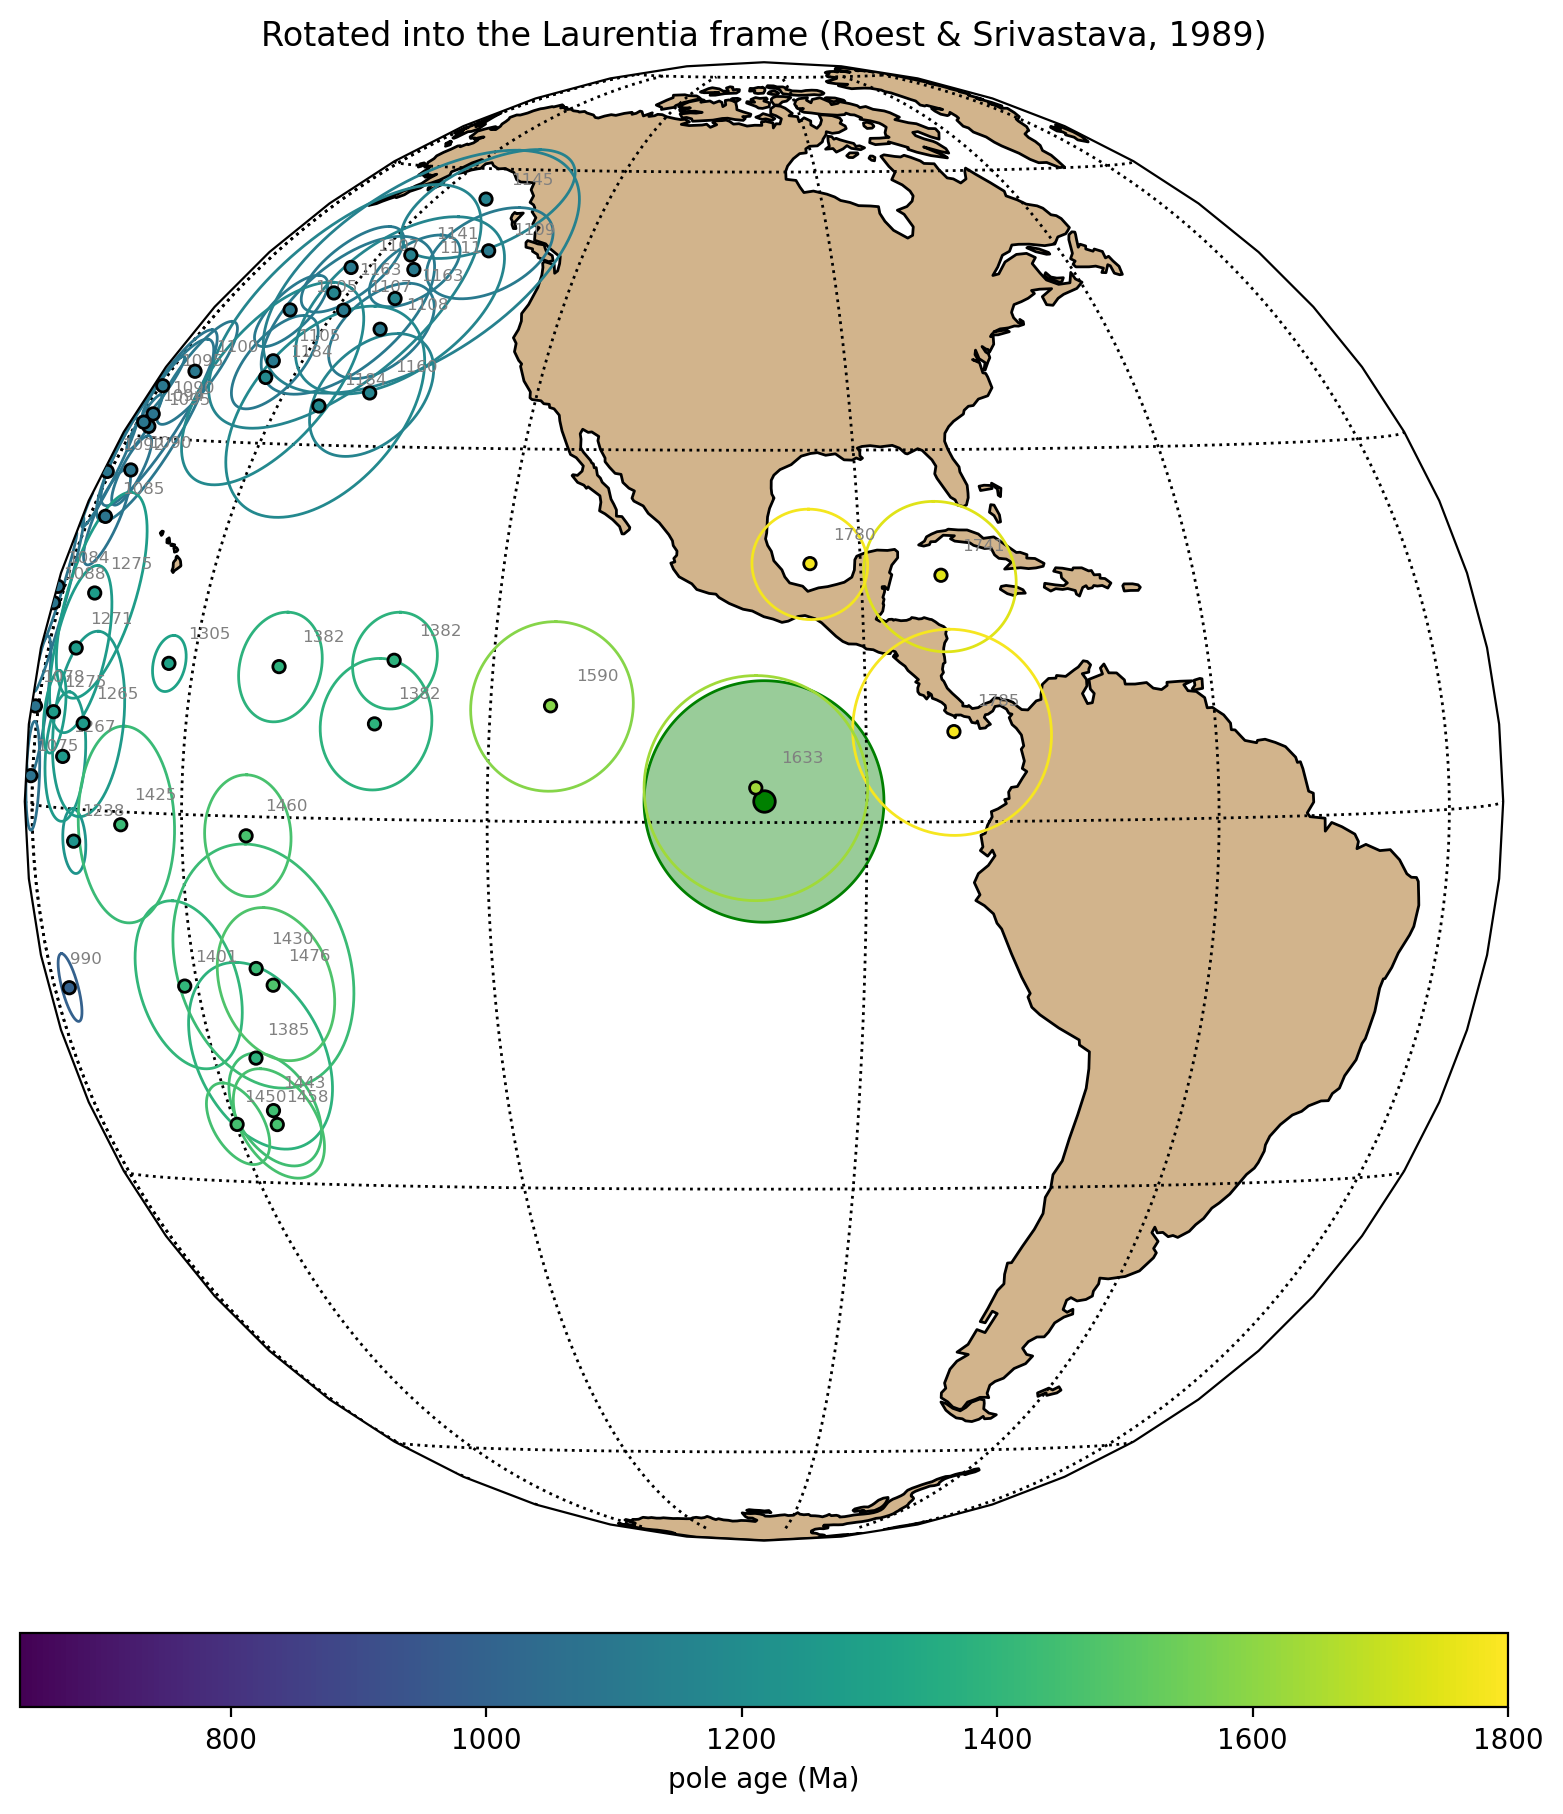

In [12]:
ax = pt.plot_apwp_context(Laurentia_poles, pole_rotated['inc'], pole_rotated['dec'],
                          pole_rotated['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_rotated['dec'],
                          central_latitude=pole_rotated['inc'])
plt.title('Rotated into the Laurentia frame (Roest & Srivastava, 1989)')
plt.show()

## R7: comparison with younger Laurentia poles

The `plot_pole_overlap` comparison is shown for both the unrotated and the rotated position.

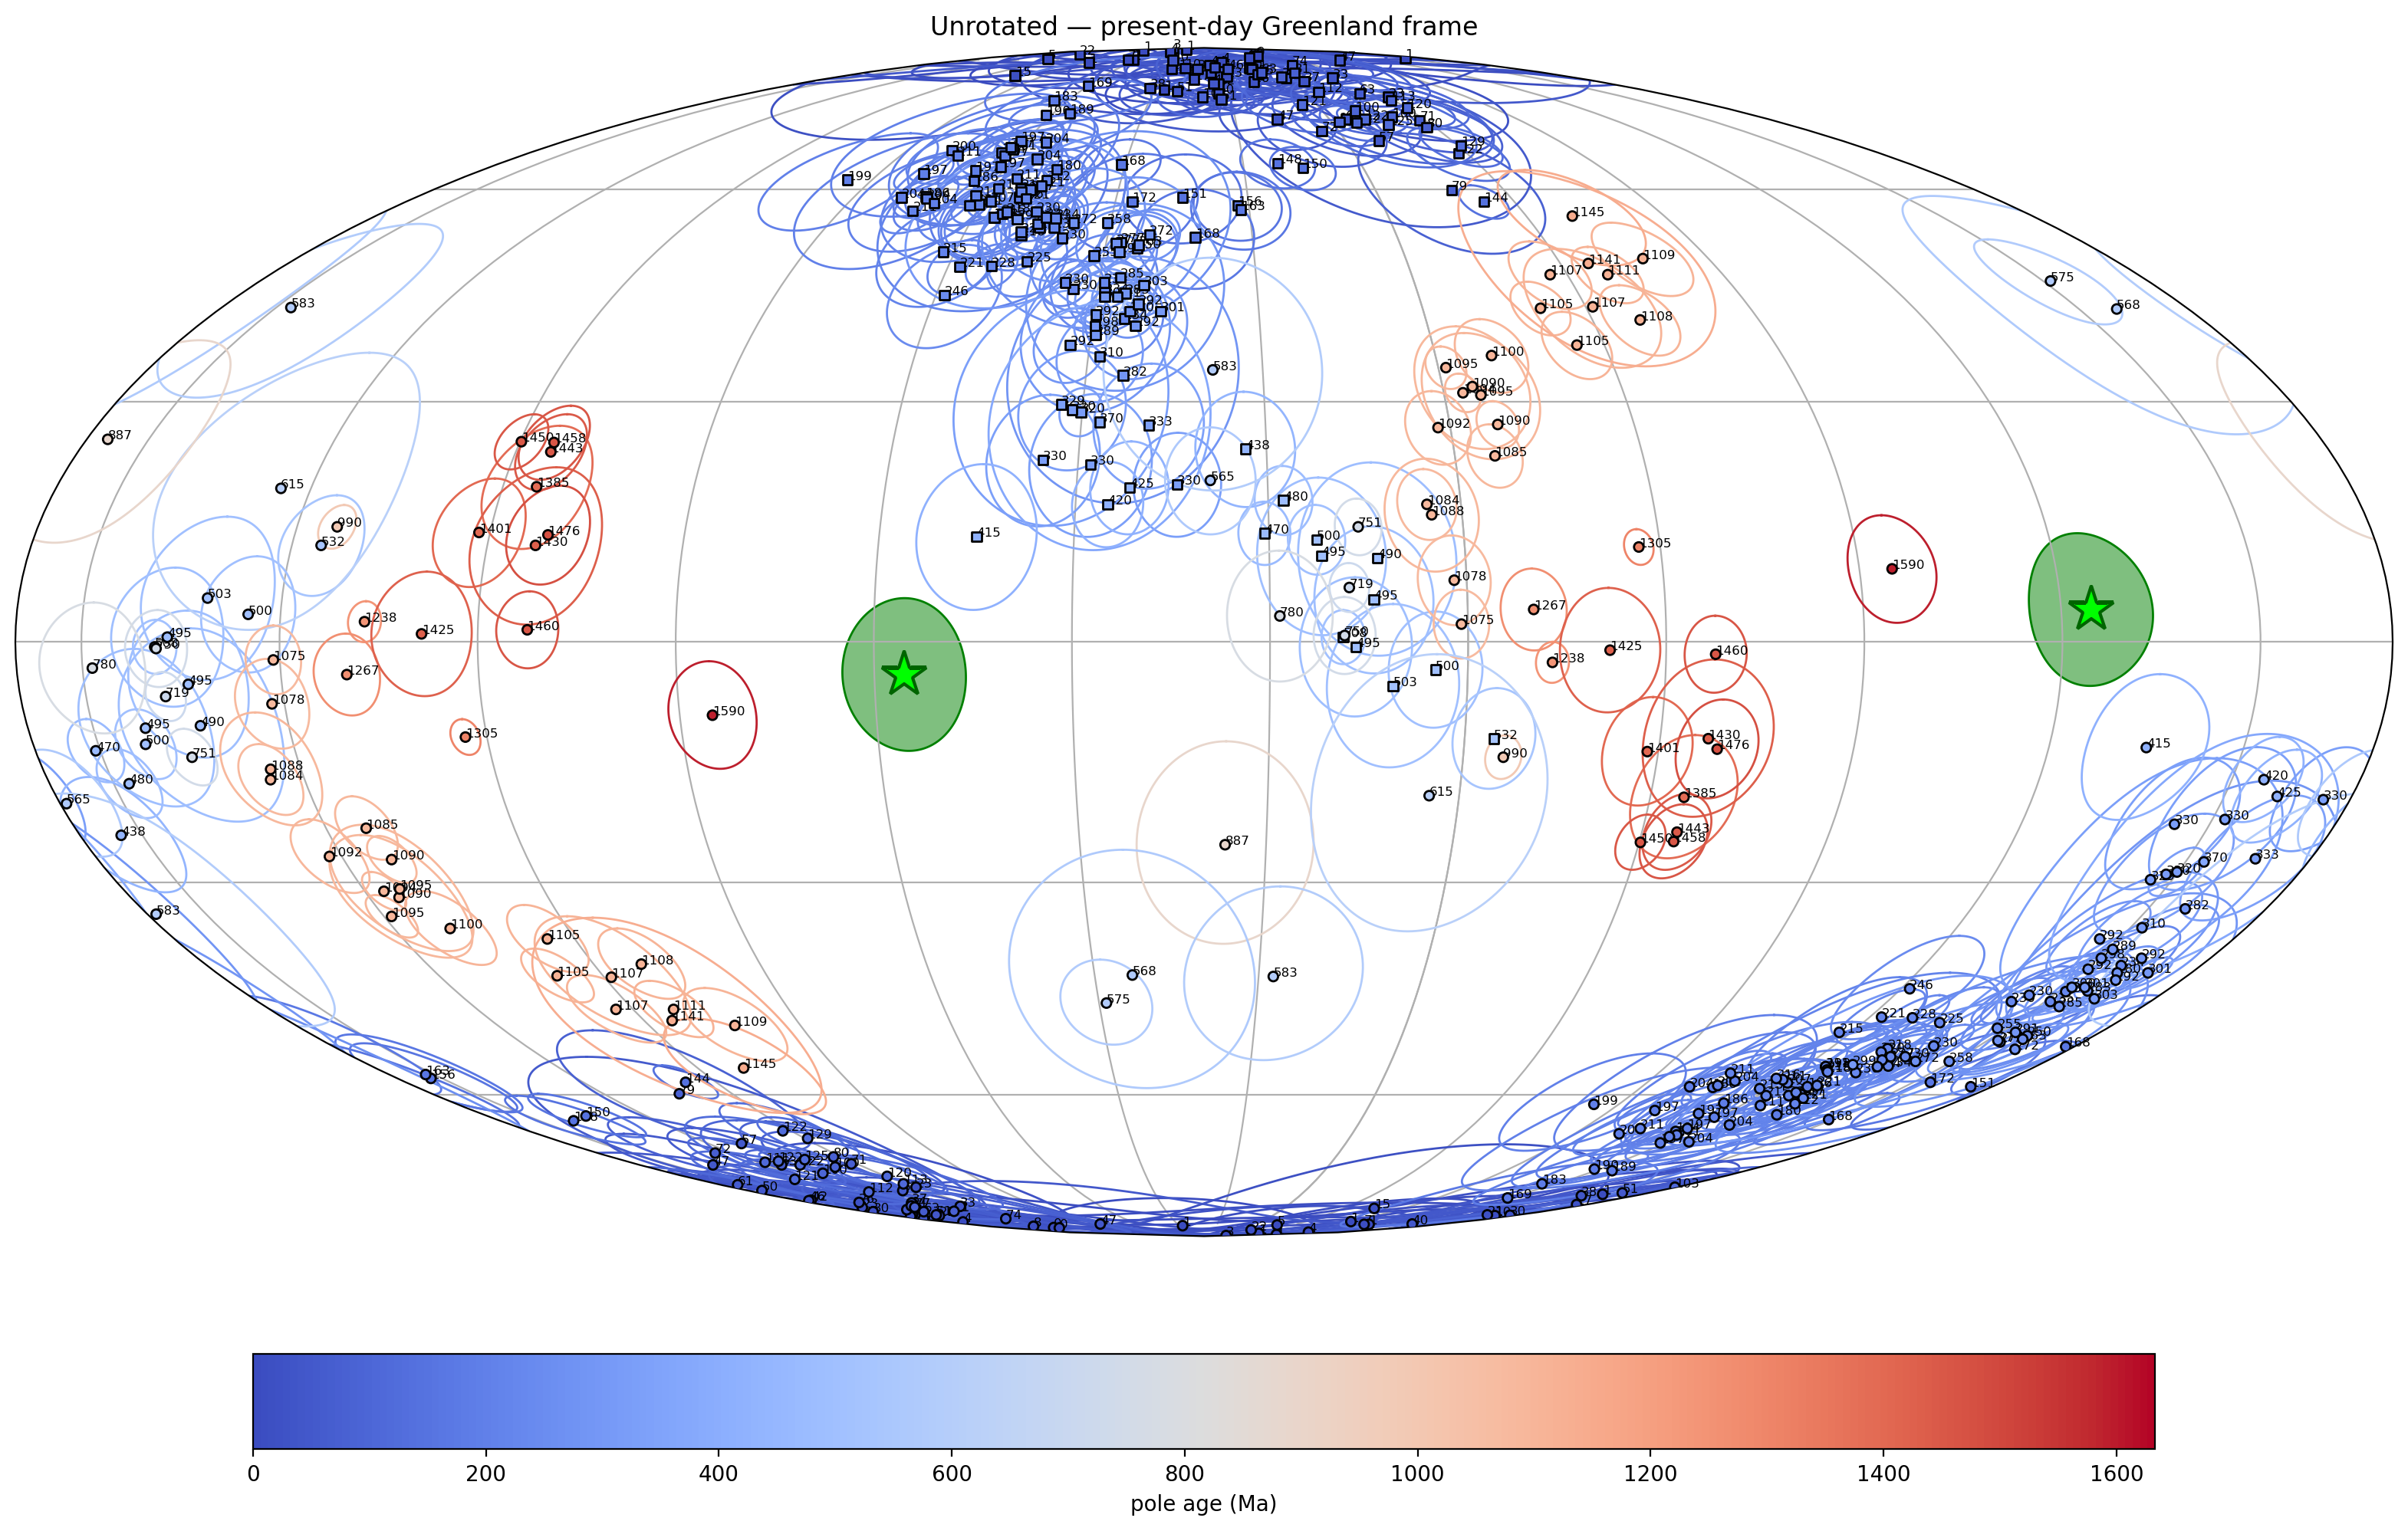

In [13]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('Melville Bugt diabase dykes', Laurentia_stricto_poles,
                     pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=1630, show=False)
plt.title('Unrotated \u2014 present-day Greenland frame')
plt.show()

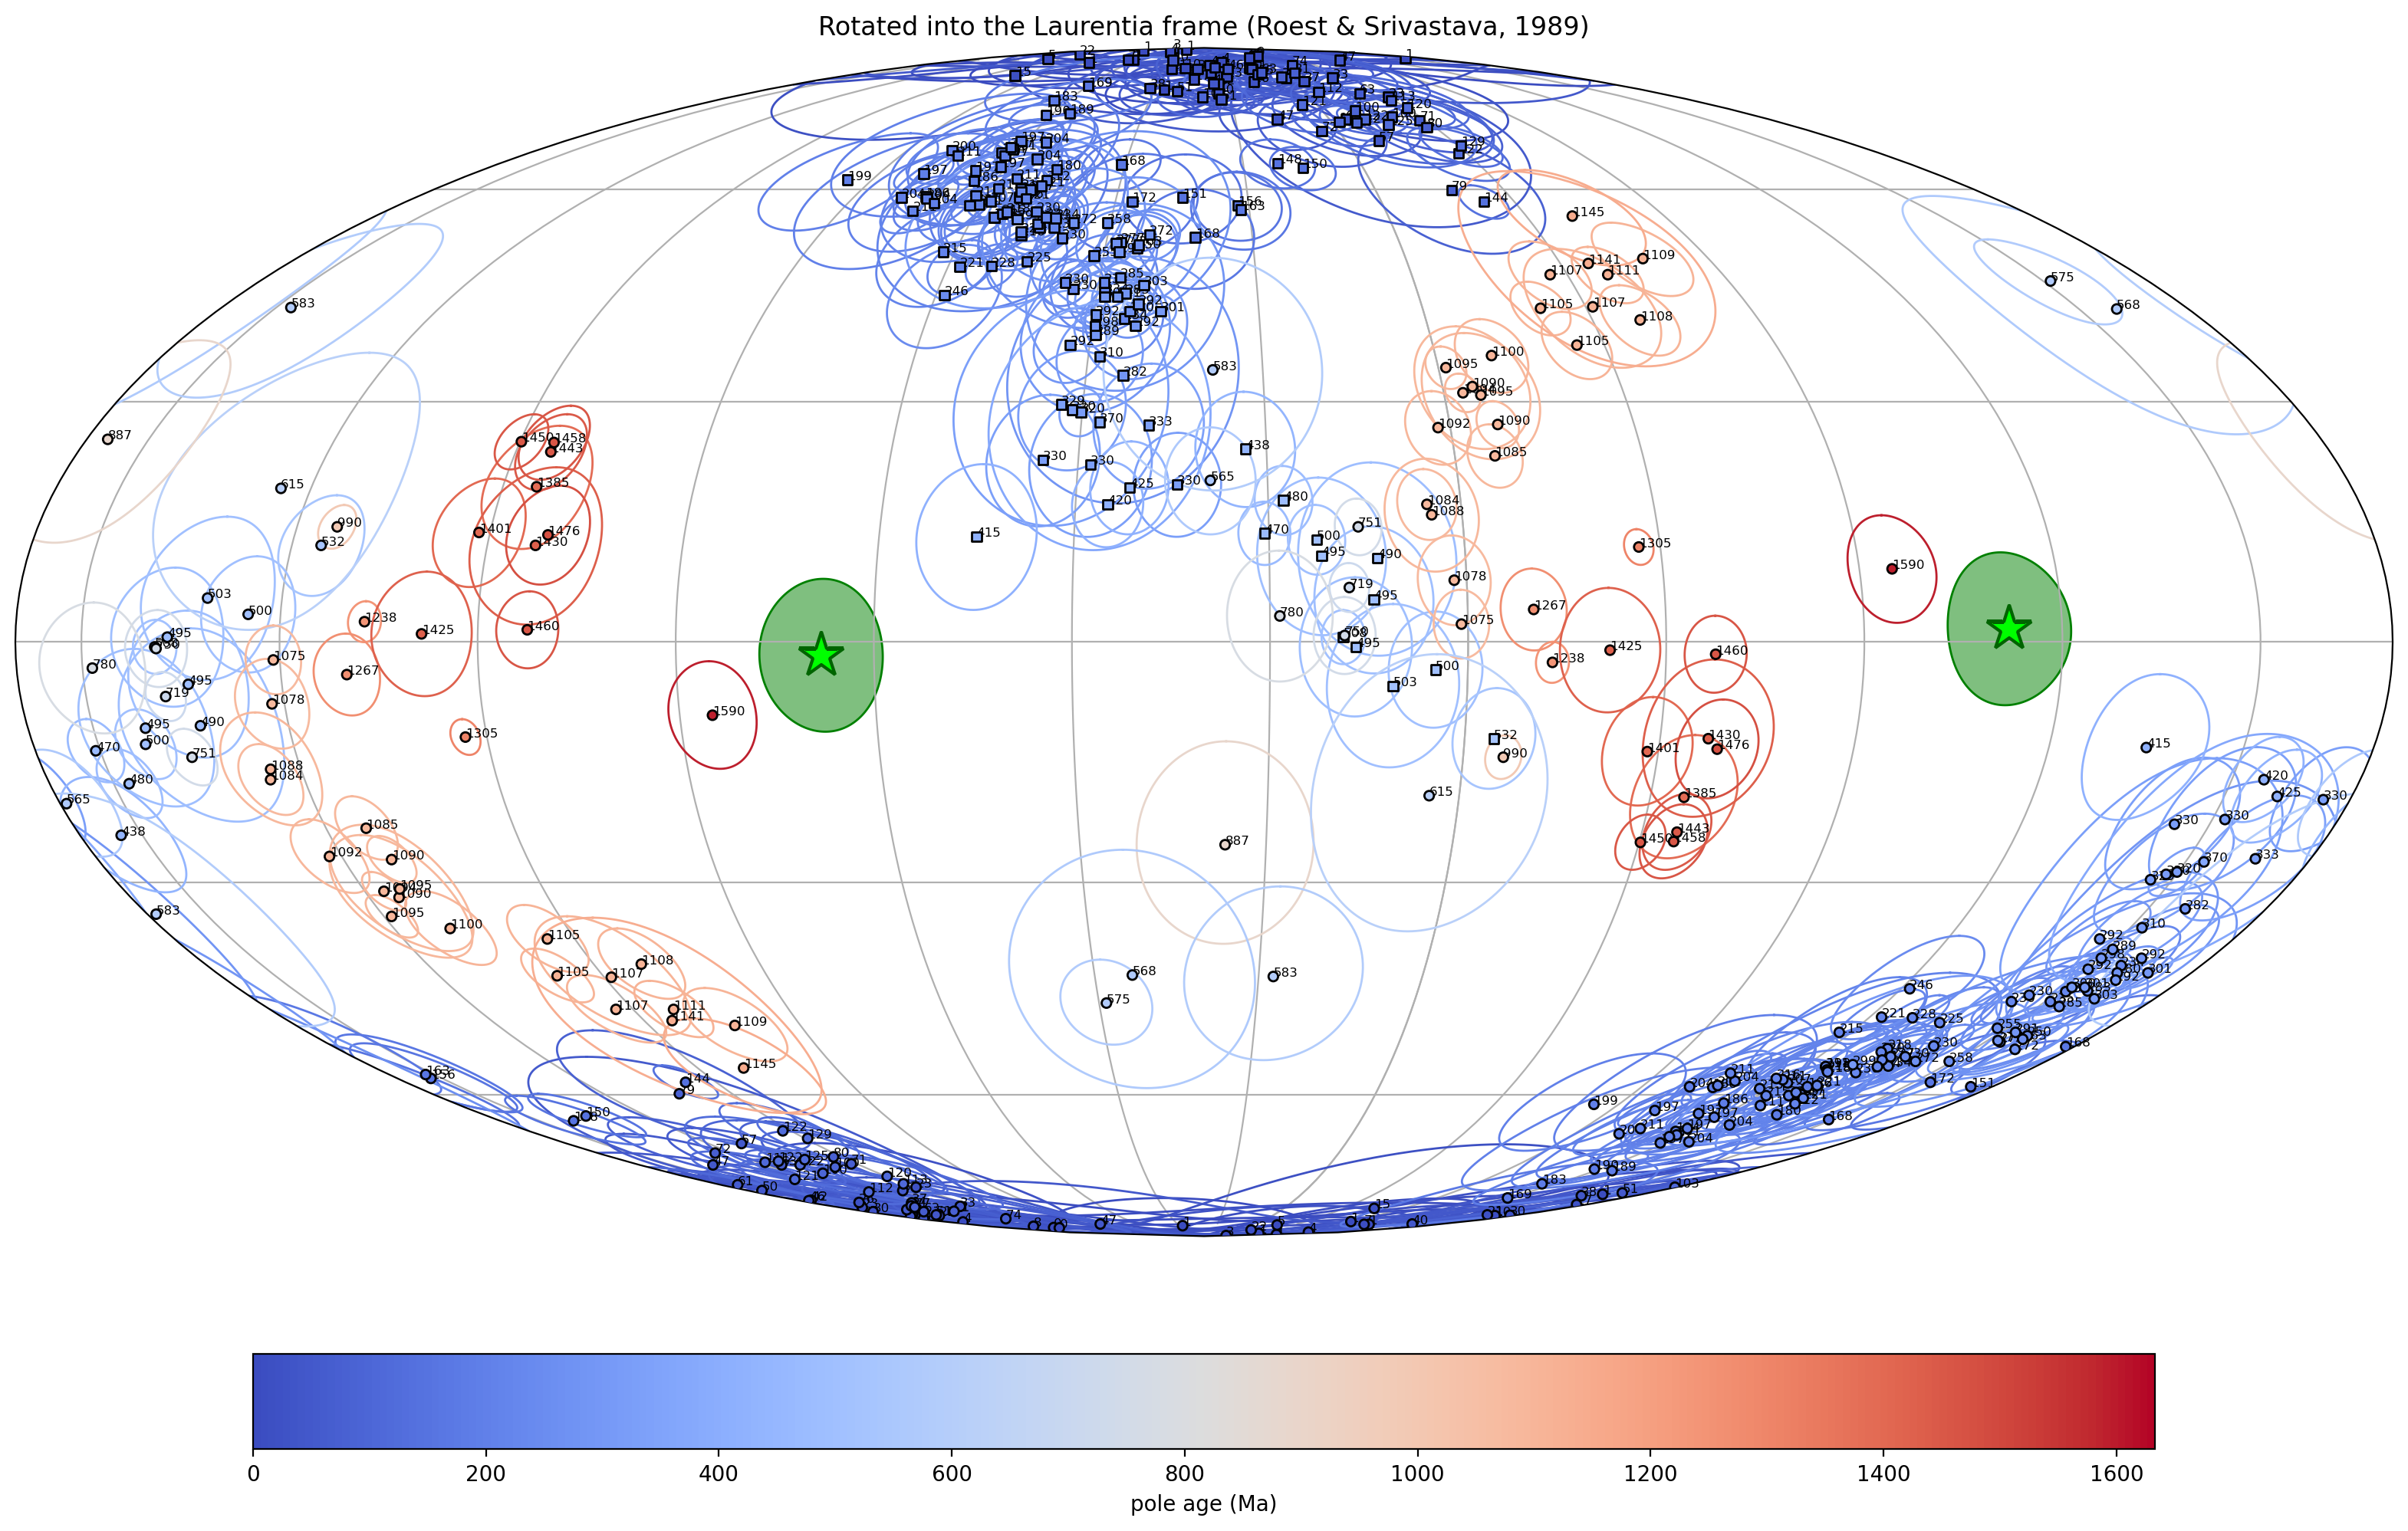

In [14]:
pt.plot_pole_overlap('Melville Bugt diabase dykes', Laurentia_stricto_poles,
                     pt.Torsvik2012_Laurentia,
                     pole_plat=pole_rotated['inc'], pole_plon=pole_rotated['dec'],
                     pole_A95=pole_rotated['alpha95'], pole_age=1630, show=False)
plt.title('Rotated into the Laurentia frame (Roest & Srivastava, 1989)')
plt.show()

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | U-Pb baddeleyite on four dykes spanning 1622.1–1635.0 Ma (2σ; Halls et al., 2011); nominal 1630 Ma. |
| 2 | Techniques and statistical analysis | **1** | AF + thermal demagnetization with vector analysis; N = 9 dyke means, K = 31.3, A95 = 9.3° passes the Deenen et al. (2011) envelope. |
| 3 | Magnetic mineralogy characterized | **1** | Magnetite remanence (thermomagnetic analysis; Denyszyn, 2008). |
| 4 | Field tests constrain age of magnetization | **0** | No baked-contact or fold test (chilled-margin sampling was used for geochemical dyke fingerprinting, not as a country-rock baked-contact test). |
| 5 | Structural control / tectonic coherence | **1** | Autochthonous NW Greenland (Laurentia-Greenland) basement; vertical dykes need no tilt correction. |
| 6 | Presence of reversals | **0** | While there is dual polarity, they do not pass a reversal test. |
| 7 | No resemblance to younger poles | **1** | Distinct from younger Laurentia poles. |
| | Total | **5/7** | Grade B |

## Nordic workshop summary

The Melville Bugt pole is recreated at the site level from the 9 primary-remanence
dykes of Halls et al. (2011). The recreation reproduces the prior compilation
pole (5°N/273.8°E, A95 8.7, GPMDB 9495) with an internally consistent k/A95 pair
(k 31.3, A95 9.3). The mixed-polarity dykes do not pass a reversal test, so R6 = 0; the swarm is well dated by U-Pb
(R1 = 1). The pole is reported at the +5 position; Halls et al. give the −5
antipode.

## Pole comparison

### Primary component pole

| | This study (site VGPs) | Halls et al. (2011) | Previous Nordic compilation |
|---|---|---|---|
| Component | Primary CRM (magnetite) | Primary CRM (magnetite) | Primary CRM (magnetite) |
| N (sites) | 9 | 9 | 9 |
| N (specimens) | 57 | — | 54 |
| Dec (°) | 208.5 | 33.1 | 33.1 |
| Inc (°) | 31.0 | −31.2 | −31.2 |
| k (direction) | 16.5 | — | 29.0 |
| α95 (direction, °) | 13.1 | — | — |
| Pole lat (°N) | 4.0 | 5.0 | 5.0 |
| Pole lon (°E) | 274.5 | 273.8 | 273.8 |
| A95, pole (°) | 9.3 | 8.7 | 8.7 |
| dp / dm (°) | — | — | 8.7 / 8.7 |


In [15]:
melville_summary = pt.make_nordic_summary(
    terrane='Laurentia-Greenland',
    rockname='Melville Bugt diabase dykes',
    sites=primary,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='',
    tests='',
    gpmdb_number='9495',
    magic_id='20713',
    percent_reversed=44,
    demag_code=4,
    R1=1, R2=1, R3=1, R4='', R5=1, R6=0, R7=1, Grade='B', Grade_E21='B',
    nominal_age=1630, lomagage=1619, himagage=1638,
    REF_method="Nominal 1630 Ma, bracket 1619-1638 Ma. U-Pb baddeleyite 207Pb/206Pb weighted-mean ages (2 sigma; Halls et al., 2011) from four dykes: 1622.1 +/- 3.2 (Olrik fjord = site OF), 1629.4 +/- 0.8 (site MB2), 1632.0 +/- 1.1 (Qeqertaq = site QT), and 1635.0 +/- 2.7 Ma (Ryder = site MB9); a fifth dyke ~1000 km SE (Snehatten) is 1629.7 +/- 3.9 Ma (Klausen & Nilsson, 2019), consistent with a prolonged >=13 Myr emplacement. All four dated dykes, including the youngest (OF, 1622 Ma), are in the 9-dyke pole, so it time-averages the ~1622-1635 Ma span; the nominal 1630 Ma is the mean of the dated pole dykes (the literature ca. 1630 Ma age) and 1619-1638 Ma is their 2 sigma envelope.",
    POLE_AUTHORS='Halls, H. C., Hamilton, M. A., & Denyszyn, S. W.',
    YEAR=2011,
    JOURNAL='Dyke Swarms: Keys for Geodynamic Interpretation (Springer)',
    VOLUME='',
    VPAGES='509-535',
    TITLE='The Melville Bugt Dyke Swarm of Greenland: A Connection to the 1.5-1.6 Ga Fennoscandian Rapakivi Granite Province?',
    COMMENT='Melville Bugt pole recreated at the site level from the 9 primary-remanence dykes of Halls et al. (2011) (audited contribution; OF chilled margin not counted as a separate dyke; QT dir_n_samples = 8, the in-mean count). Recreated 4.0N/274.5E with an internally consistent k=31.3/A95=9.3 (the source mixed the paper A95 8.7 with a recomputed k); reproduces the prior compilation pole (5N/273.8E, GPMDB 9495). Mixed polarity but equivocal reversal test -> R6=0; U-Pb ca. 1630 Ma -> R1=1. No field test (R4=0). Grade B.'
)
pt.save_nordic_summary(melville_summary, '1630_Melville_Bugt')
melville_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia-Greenland,Melville Bugt diabase dykes,GPMDB:9495,,,0,74.4,301.6,9,57,...,1638,"- Current bracket: nominal age 1633 Ma, lomaga...",Melville Bugt diabase dykes,"Halls, H. C., Hamilton, M. A., & Denyszyn, S. W.",2011,Dyke Swarms: Keys for Geodynamic Interpretatio...,,509-535,The Melville Bugt Dyke Swarm of Greenland: A C...,Melville Bugt pole recreated at the site level...
